In [25]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns
matplotlib_font_size=7
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = matplotlib_font_size


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_search_performance"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [26]:
steps=[
    "open_search", 
    "neutral_loss_search",
    "hybrid_search"
    ]

library_size=1_000_000
query_size=100
ion_mode=[-1, 1]


In [27]:

df=[]
for charge in ion_mode:
    for i in range(query_size):
        data={"total_library_number":library_size, "query_idx":i, "charge":charge}
        
        for step in steps:       
            
            # path_benchmark_dynamic_fast_search=path_benchmark_data/f"dynamic_fast_search_{charge}_{library_size}_compare_time_{step}_step_query_{i}.txt"
            path_benchmark_dynamic_fast_update=path_benchmark_data/f"dynamic_fast_update_{charge}_{library_size}_compare_time_{step}_step_query_{i}.txt"
            path_benchmark_dynamic_convert_to_flash=path_benchmark_data/f"dynamic_convert_to_flash_{charge}_{library_size}_compare_time_{step}_step_query_{i}.txt"
            path_benchmark_flash=path_benchmark_data/f"flash_{charge}_{library_size}_compare_time_{step}_step_query_{i}.txt"
            try:
                path_benchmark_masstplus=path_benchmark_data/f"masstplus_{charge}_{library_size}_compare_time_{step}_step_query_{i}.txt"
                with open(path_benchmark_masstplus,"r") as f:    
                    masstplus=float(f.readline().strip())
                data["masstplus"]=masstplus
            except:
                data["masstplus"]=None

            # with open(path_benchmark_dynamic_fast_search,"r") as f:
            #     dynamic_fast_search=float(f.readline().strip())

            with open(path_benchmark_dynamic_fast_update,"r") as f:
                dynamic_fast_update=float(f.readline().strip())

            with open(path_benchmark_dynamic_convert_to_flash,"r") as f:
                dynamic_convert_to_flash=float(f.readline().strip())

            with open(path_benchmark_flash,"r") as f:    
                flash=float(f.readline().strip())

               

            # data["dynamic_entropy_search(fast_search)"]=dynamic_fast_search
            data["dynamic_entropy_search(fast_update)"]=dynamic_fast_update
            data["dynamic_entropy_search(convert_to_flash)"]=dynamic_convert_to_flash
            data["flash_entropy_search"]=flash
            data["search_type"]=step

                            
                        
            df.append(pd.DataFrame([data]))
        
df=pd.concat(df)
            
df


,total_library_number,query_idx,charge,masstplus,dynamic_entropy_search(fast_update),dynamic_entropy_search(convert_to_flash),flash_entropy_search,search_type
0,1000000,0,-1,None,0.011337,0.005488,0.007991,open_search
0,1000000,0,-1,None,0.011880,0.014726,0.007964,neutral_loss_search
0,1000000,0,-1,8.500278,0.072314,0.062310,0.055108,hybrid_search
0,1000000,1,-1,None,0.006613,0.003268,0.004240,open_search
0,1000000,1,-1,None,0.013701,0.005056,0.003927,neutral_loss_search
...,...,...,...,...,...,...,...,...
0,1000000,98,1,None,0.015319,0.007684,0.008238,neutral_loss_search
0,1000000,98,1,7.499696,0.130250,0.112515,0.103657,hybrid_search
0,1000000,99,1,None,0.005699,0.005616,0.005813,open_search
0,1000000,99,1,None,0.006633,0.003360,0.003887,neutral_loss_search


In [28]:

df_data = df[["search_type", 
            "dynamic_entropy_search(fast_update)",
            # "dynamic_entropy_search(convert_to_flash)", 
            "flash_entropy_search",
            "masstplus",
            "charge"]]
    
df_melted=df_data.melt(id_vars=["charge", "search_type"], var_name="method", value_name="time")
df_melted        
        


,charge,search_type,method,time
0,-1,open_search,dynamic_entropy_search(fast_update),0.011337
1,-1,neutral_loss_search,dynamic_entropy_search(fast_update),0.01188
2,-1,hybrid_search,dynamic_entropy_search(fast_update),0.072314
3,-1,open_search,dynamic_entropy_search(fast_update),0.006613
4,-1,neutral_loss_search,dynamic_entropy_search(fast_update),0.013701
...,...,...,...,...
1795,1,neutral_loss_search,masstplus,None
1796,1,hybrid_search,masstplus,7.499696
1797,1,open_search,masstplus,None
1798,1,neutral_loss_search,masstplus,None


In [29]:
my_color_palette = sns.color_palette("Set3", 12)

color_palette={
    
    "dynamic_entropy_search(fast_update)": my_color_palette[4],
    "dynamic_entropy_search(convert_to_flash)": my_color_palette[6],
    "flash_entropy_search":my_color_palette[3],
    "masstplus":my_color_palette[-3]

}

In [ ]:
def plot_time_different_search_1M(
    charge,
    df_melted,
    color_palette,
    ylim,
    save_path

):
    df_charge=df_melted[df_melted["charge"]==charge]
    hue_order=[
        "dynamic_entropy_search(fast_update)", 
        # "dynamic_entropy_search(convert_to_flash)", 
        "flash_entropy_search", "masstplus"]
    legend_labels = {
    "dynamic_entropy_search(fast_update)": "Dynamic Entropy Search", 
    # "dynamic_entropy_search(convert_to_flash)": "Dynamic Entropy Search (with index converted)",
    "flash_entropy_search": "Flash Entropy Search",
    "masstplus": "MASST+"
    }
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3, 2.4), width_ratios=[1,1,1], sharex=False, sharey=True)
    if charge==-1:
        mode="-"
    elif charge==1:
        mode="+"
    for i, search in enumerate(["open_search", "neutral_loss_search", "hybrid_search"]):
        df_plot=df_charge[df_charge["search_type"]==search]
        ax=axes[i]
        ax.grid(True, which="both", axis="y", ls="-", alpha=0.5, linewidth=0.4)
        ax.set_title(search.replace("_"," ").title(), fontsize=matplotlib_font_size)

        sns.stripplot(x="method", y="time", hue="method", data=df_plot, hue_order=hue_order, palette=color_palette, dodge=False, jitter=0.25, size=1, alpha=0.5, linewidth=0, ax=ax)        
                
        sns.boxplot(x="method", y="time", hue="method", data=df_plot, hue_order=hue_order, dodge=False, palette=color_palette, linewidth=0.4, width=0.6, ax=ax, fliersize=0)
        
        ax.tick_params(which="both", width=0.4)          
        for spine in ax.spines.values():  
            spine.set_linewidth(0.4)
            
        ax.legend().remove()

        ax.set_yscale("log")
        bottom=ylim[0]
        top=ylim[1]
        ax.set_ylim(bottom=bottom, top=top)
        ax.set_ylabel("Library Search Time (s)")
        ax.set_xlabel("")
        ax.set_xticklabels([])
        ax.set_xticks([])

    

    handles = []
    for method in hue_order:
        handle = plt.Line2D([0], [0], marker='o', color=color_palette[method], 
                        markersize=3, linestyle='',label=legend_labels.get(method, method))
        handles.append(handle)

    fig.legend(handles=handles, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 1.2), 
            ncol=4, 
            fontsize=matplotlib_font_size,
            frameon=False)

    fig.text(0.55, 0.2, f'({mode}) ESI', 
            ha='center', 
            fontsize=matplotlib_font_size,
            )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    # Save figure
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)

    

/tmp/ipykernel_27996/2004220484.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_27996/2004220484.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_27996/2004220484.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


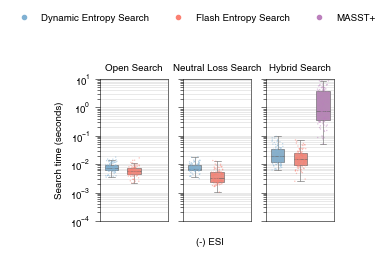

In [31]:
charge=-1
ylim=(1e-4,1e1)
save_path=path_figures / f"compare_time_different_search_methods_charge_{charge}_lib_scale_1M_3_methods.svg"
plot_time_different_search_1M(
    charge=charge,
    df_melted=df_melted,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)

/tmp/ipykernel_27996/2004220484.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_27996/2004220484.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_27996/2004220484.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


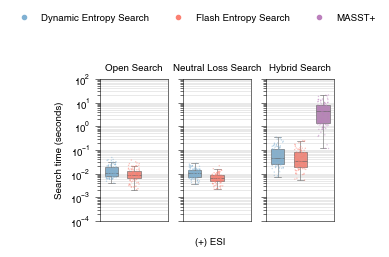

In [32]:
charge=1
ylim=(1e-4,1e2)
save_path=path_figures / f"compare_time_different_search_methods_charge_{charge}_lib_scale_1M_3_methods.svg"
plot_time_different_search_1M(
    charge=charge,
    df_melted=df_melted,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)